# 1. Target: SalePrice

Continues from [0_load_and_orient.ipynb](0_load_and_orient.ipynb) — reloads
the same setup so this notebook runs standalone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, boxcox

In [2]:
# load csv data for both train and test
df_train = pd.read_csv("../../data/train.csv")
df_test = pd.read_csv("../../data/test.csv")

In [3]:
# Feature type categorization, from data_description.txt
# each list is sorted() so the final order is alphabetical regardless of
# how the source below groups them (kept grouped here for readability)

IDENTIFIER = ["Id"]
TARGET = ["SalePrice"]

NUMERIC_COLS = sorted([
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    # temporal — usually engineered into ages/deltas rather than used raw
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold",
])

# has a genuine order -> integer-encode in that order, don't one-hot
ORDINAL_COLS = sorted([
    "OverallQual", "OverallCond", "LotShape", "LandSlope",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
    "Functional", "FireplaceQu", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Utilities",
])

# no inherent order -> one-hot/dummy encode
NOMINAL_COLS = sorted([
    "MSSubClass",  # gotcha: stored as int, but it's a dwelling-type code
    "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
])

all_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
expected = set(df_train.columns) - set(IDENTIFIER) - set(TARGET)
assert set(all_cols) == expected, set(all_cols) ^ expected
assert len(all_cols) == len(expected)  # no duplicates
len(NUMERIC_COLS), len(ORDINAL_COLS), len(NOMINAL_COLS)

(33, 21, 25)

In [4]:
df_train.SalePrice

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [5]:
# check null values in target
df_train["SalePrice"].isnull().sum()

np.int64(0)

In [6]:
# descriptive stats summary
df_train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice'>

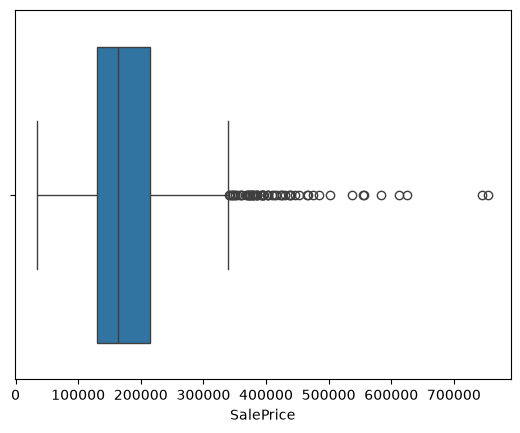

In [7]:
# boxplot
sns.boxplot(x=df_train["SalePrice"], orient="h")

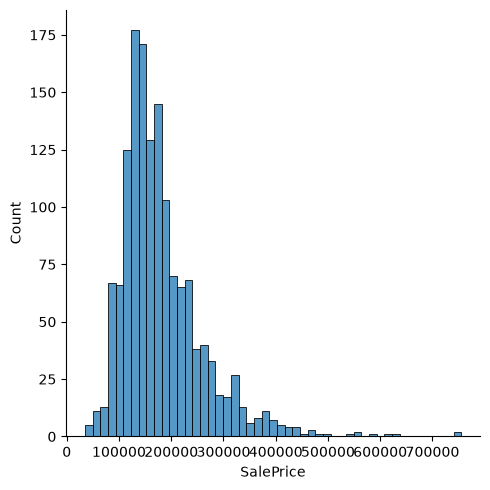

In [8]:
# histogram
sns.displot(x = df_train["SalePrice"])

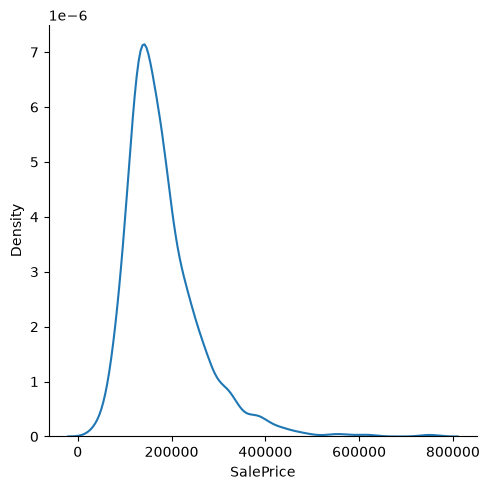

In [9]:
sns.displot(x = df_train["SalePrice"], kind="kde")

<Axes: xlabel='SalePrice', ylabel='Count'>

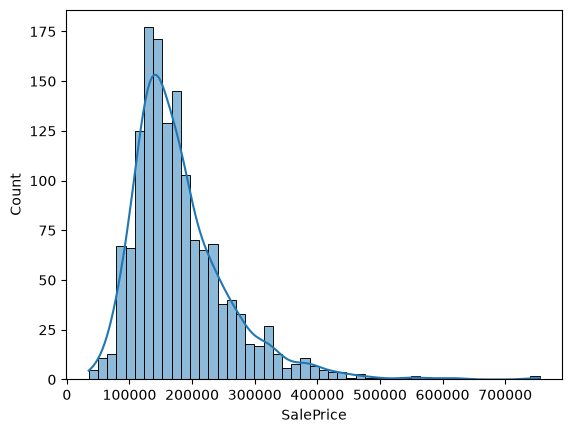

In [10]:
sns.histplot(x = df_train["SalePrice"], kde=True)

In [11]:
# outlier range
q1 = df_train["SalePrice"].quantile(0.25)
q3 = df_train["SalePrice"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
lower, upper

(np.float64(3937.5), np.float64(340037.5))

In [12]:
outliers = df_train[(df_train["SalePrice"] < lower) | (df_train["SalePrice"] > upper)]
outliers[["Id", "SalePrice"]]

,Id,SalePrice
11,12,345000
53,54,385000
58,59,438780
112,113,383970
151,152,372402
...,...,...
1268,1269,381000
1353,1354,410000
1373,1374,466500
1388,1389,377500


In [13]:
(outliers.Id).shape

(61,)

In [14]:
# median, mean, std, skewness, kurtosis
print("median:", df_train["SalePrice"].median())
print("mean:", df_train["SalePrice"].mean())
print("std:", df_train["SalePrice"].std())
print("skew:", df_train["SalePrice"].skew())
print("kurt:", df_train["SalePrice"].kurt())


median: 163000.0
mean: 180921.19589041095
std: 79442.50288288662
skew: 1.8828757597682129
kurt: 6.536281860064529


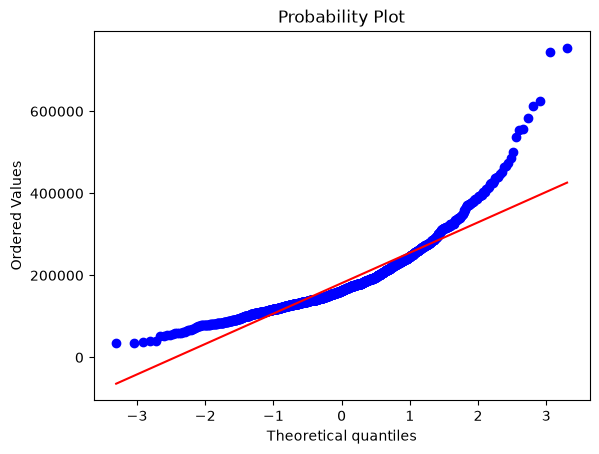

In [15]:
# QQ-Plot: raw SalePrice
probplot(df_train["SalePrice"], plot=plt)
plt.show()

In [16]:
# log transform using log1p
log_sale_price = pd.Series(np.log1p(df_train["SalePrice"]))
log_sale_price.name = "log_sale_price"
log_sale_price

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: log_sale_price, Length: 1460, dtype: float64

<Axes: xlabel='log_sale_price', ylabel='Count'>

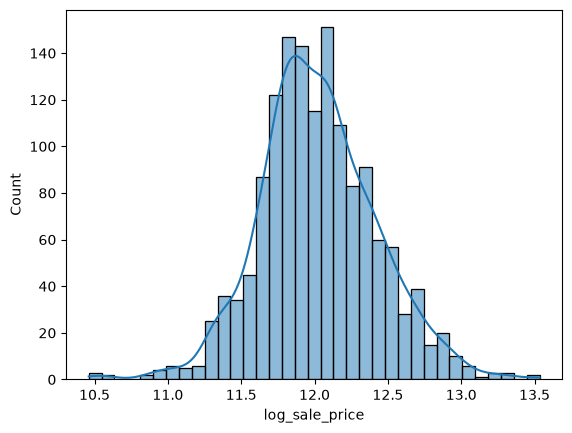

In [17]:
# histplot on log_sale_price
sns.histplot(x = log_sale_price, kde=True, )

In [18]:
# median, mean, std, skewness, kurtosis of log sale price
print("median:", log_sale_price.median())
print("mean:", log_sale_price.mean())
print("std:", log_sale_price.std())
print("skew:", log_sale_price.skew())
print("kurt:", log_sale_price.kurt())

median: 12.001511614739405
mean: 12.024057394918406
std: 0.3994492733225068
skew: 0.12134661989685333
kurt: 0.809519155707878


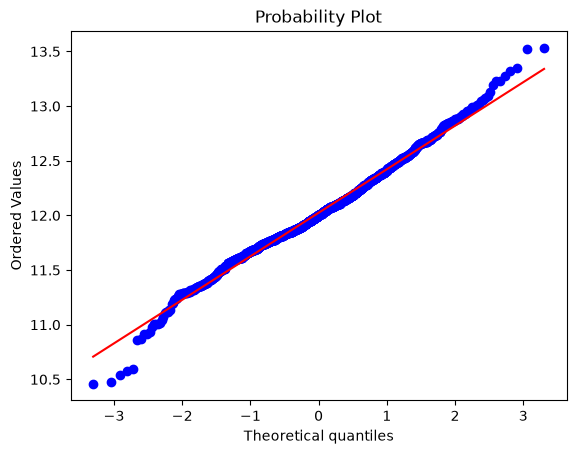

In [19]:
# QQ-Plot: log sale price
probplot(log_sale_price, plot=plt)
plt.show()

<Axes: xlabel='log_sale_price'>

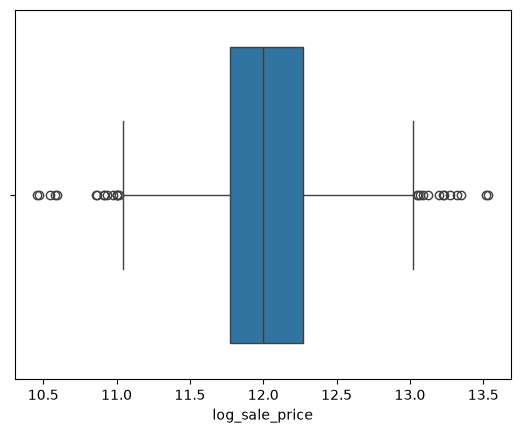

In [20]:
sns.boxplot(x = log_sale_price, orient="h")

In [21]:
# outliers in log sale price
q1 = log_sale_price.quantile(0.25)
q3 = log_sale_price.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = log_sale_price[(log_sale_price < lower) | (log_sale_price > upper)]
len(outliers)


28

In [22]:
# left and right outliers count
low_outliers = log_sale_price[log_sale_price < lower]
high_outliers = log_sale_price[log_sale_price > upper]
len(low_outliers), len(high_outliers)


(15, 13)

In [23]:
# standard scaled sale price
scaled_sale_price = (df_train["SalePrice"] - df_train["SalePrice"].mean()) / df_train["SalePrice"].std()
scaled_sale_price

0       0.347154
1       0.007286
2       0.535970
3      -0.515105
4       0.869545
          ...   
1455   -0.074534
1456    0.366036
1457    1.077242
1458   -0.488356
1459   -0.420697
Name: SalePrice, Length: 1460, dtype: float64

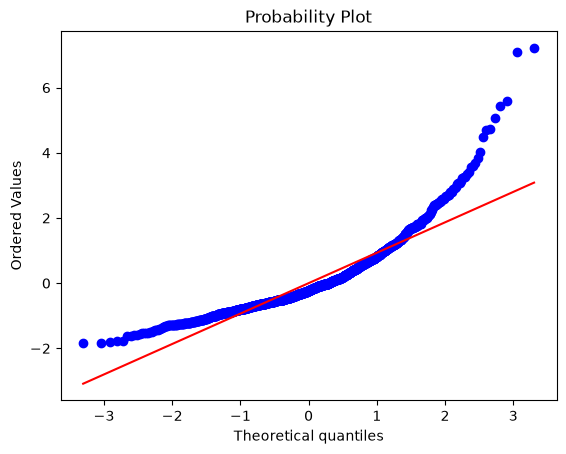

In [24]:
# QQ-Plot: scaled sale price
probplot(scaled_sale_price, plot=plt)
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

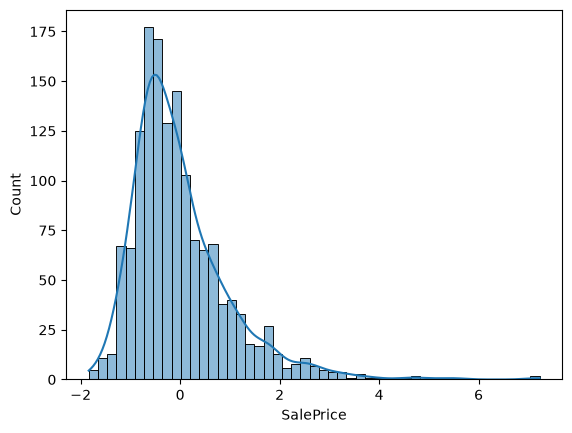

In [25]:
# histplot
sns.histplot(x = scaled_sale_price, kde=True)

In [26]:
# QQ-Plot: scaled log sale price
scaled_log_sale_price= (log_sale_price - log_sale_price.mean()) / log_sale_price.std()
scaled_log_sale_price

0       0.559875
1       0.212690
2       0.733795
3      -0.437233
4       1.014304
          ...   
1455    0.121391
1456    0.577821
1457    1.174307
1458   -0.399520
1459   -0.306590
Name: log_sale_price, Length: 1460, dtype: float64

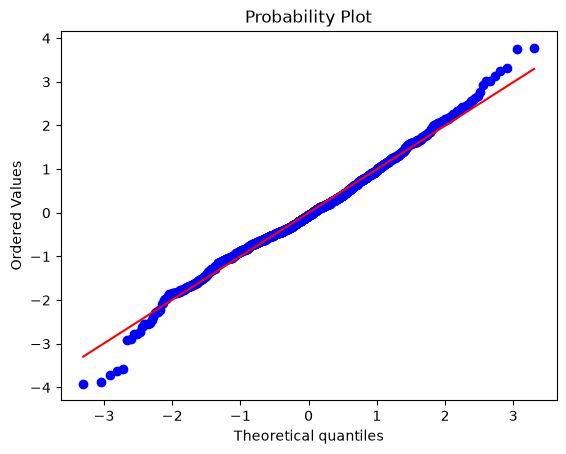

In [27]:
probplot(scaled_log_sale_price, plot=plt)
plt.show()

In [28]:
print(f"Scaled log sale price kurtosis: {scaled_log_sale_price.kurt()}")

Scaled log sale price kurtosis: 0.8095191557078785


In [29]:
df_train[NUMERIC_COLS].skew().sort_values(ascending=False)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -0.649415
dtype: float64

In [30]:
(df_train[NUMERIC_COLS] == 0).mean().sort_values(ascending=False)

PoolArea         0.995205
3SsnPorch        0.983562
LowQualFinSF     0.982192
MiscVal          0.964384
BsmtHalfBath     0.943836
ScreenPorch      0.920548
BsmtFinSF2       0.885616
EnclosedPorch    0.857534
HalfBath         0.625342
MasVnrArea       0.589726
BsmtFullBath     0.586301
2ndFlrSF         0.567808
WoodDeckSF       0.521233
Fireplaces       0.472603
OpenPorchSF      0.449315
BsmtFinSF1       0.319863
BsmtUnfSF        0.080822
GarageArea       0.055479
GarageCars       0.055479
TotalBsmtSF      0.025342
FullBath         0.006164
BedroomAbvGr     0.004110
KitchenAbvGr     0.000685
1stFlrSF         0.000000
GarageYrBlt      0.000000
GrLivArea        0.000000
MoSold           0.000000
LotArea          0.000000
LotFrontage      0.000000
TotRmsAbvGrd     0.000000
YearBuilt        0.000000
YearRemodAdd     0.000000
YrSold           0.000000
dtype: float64

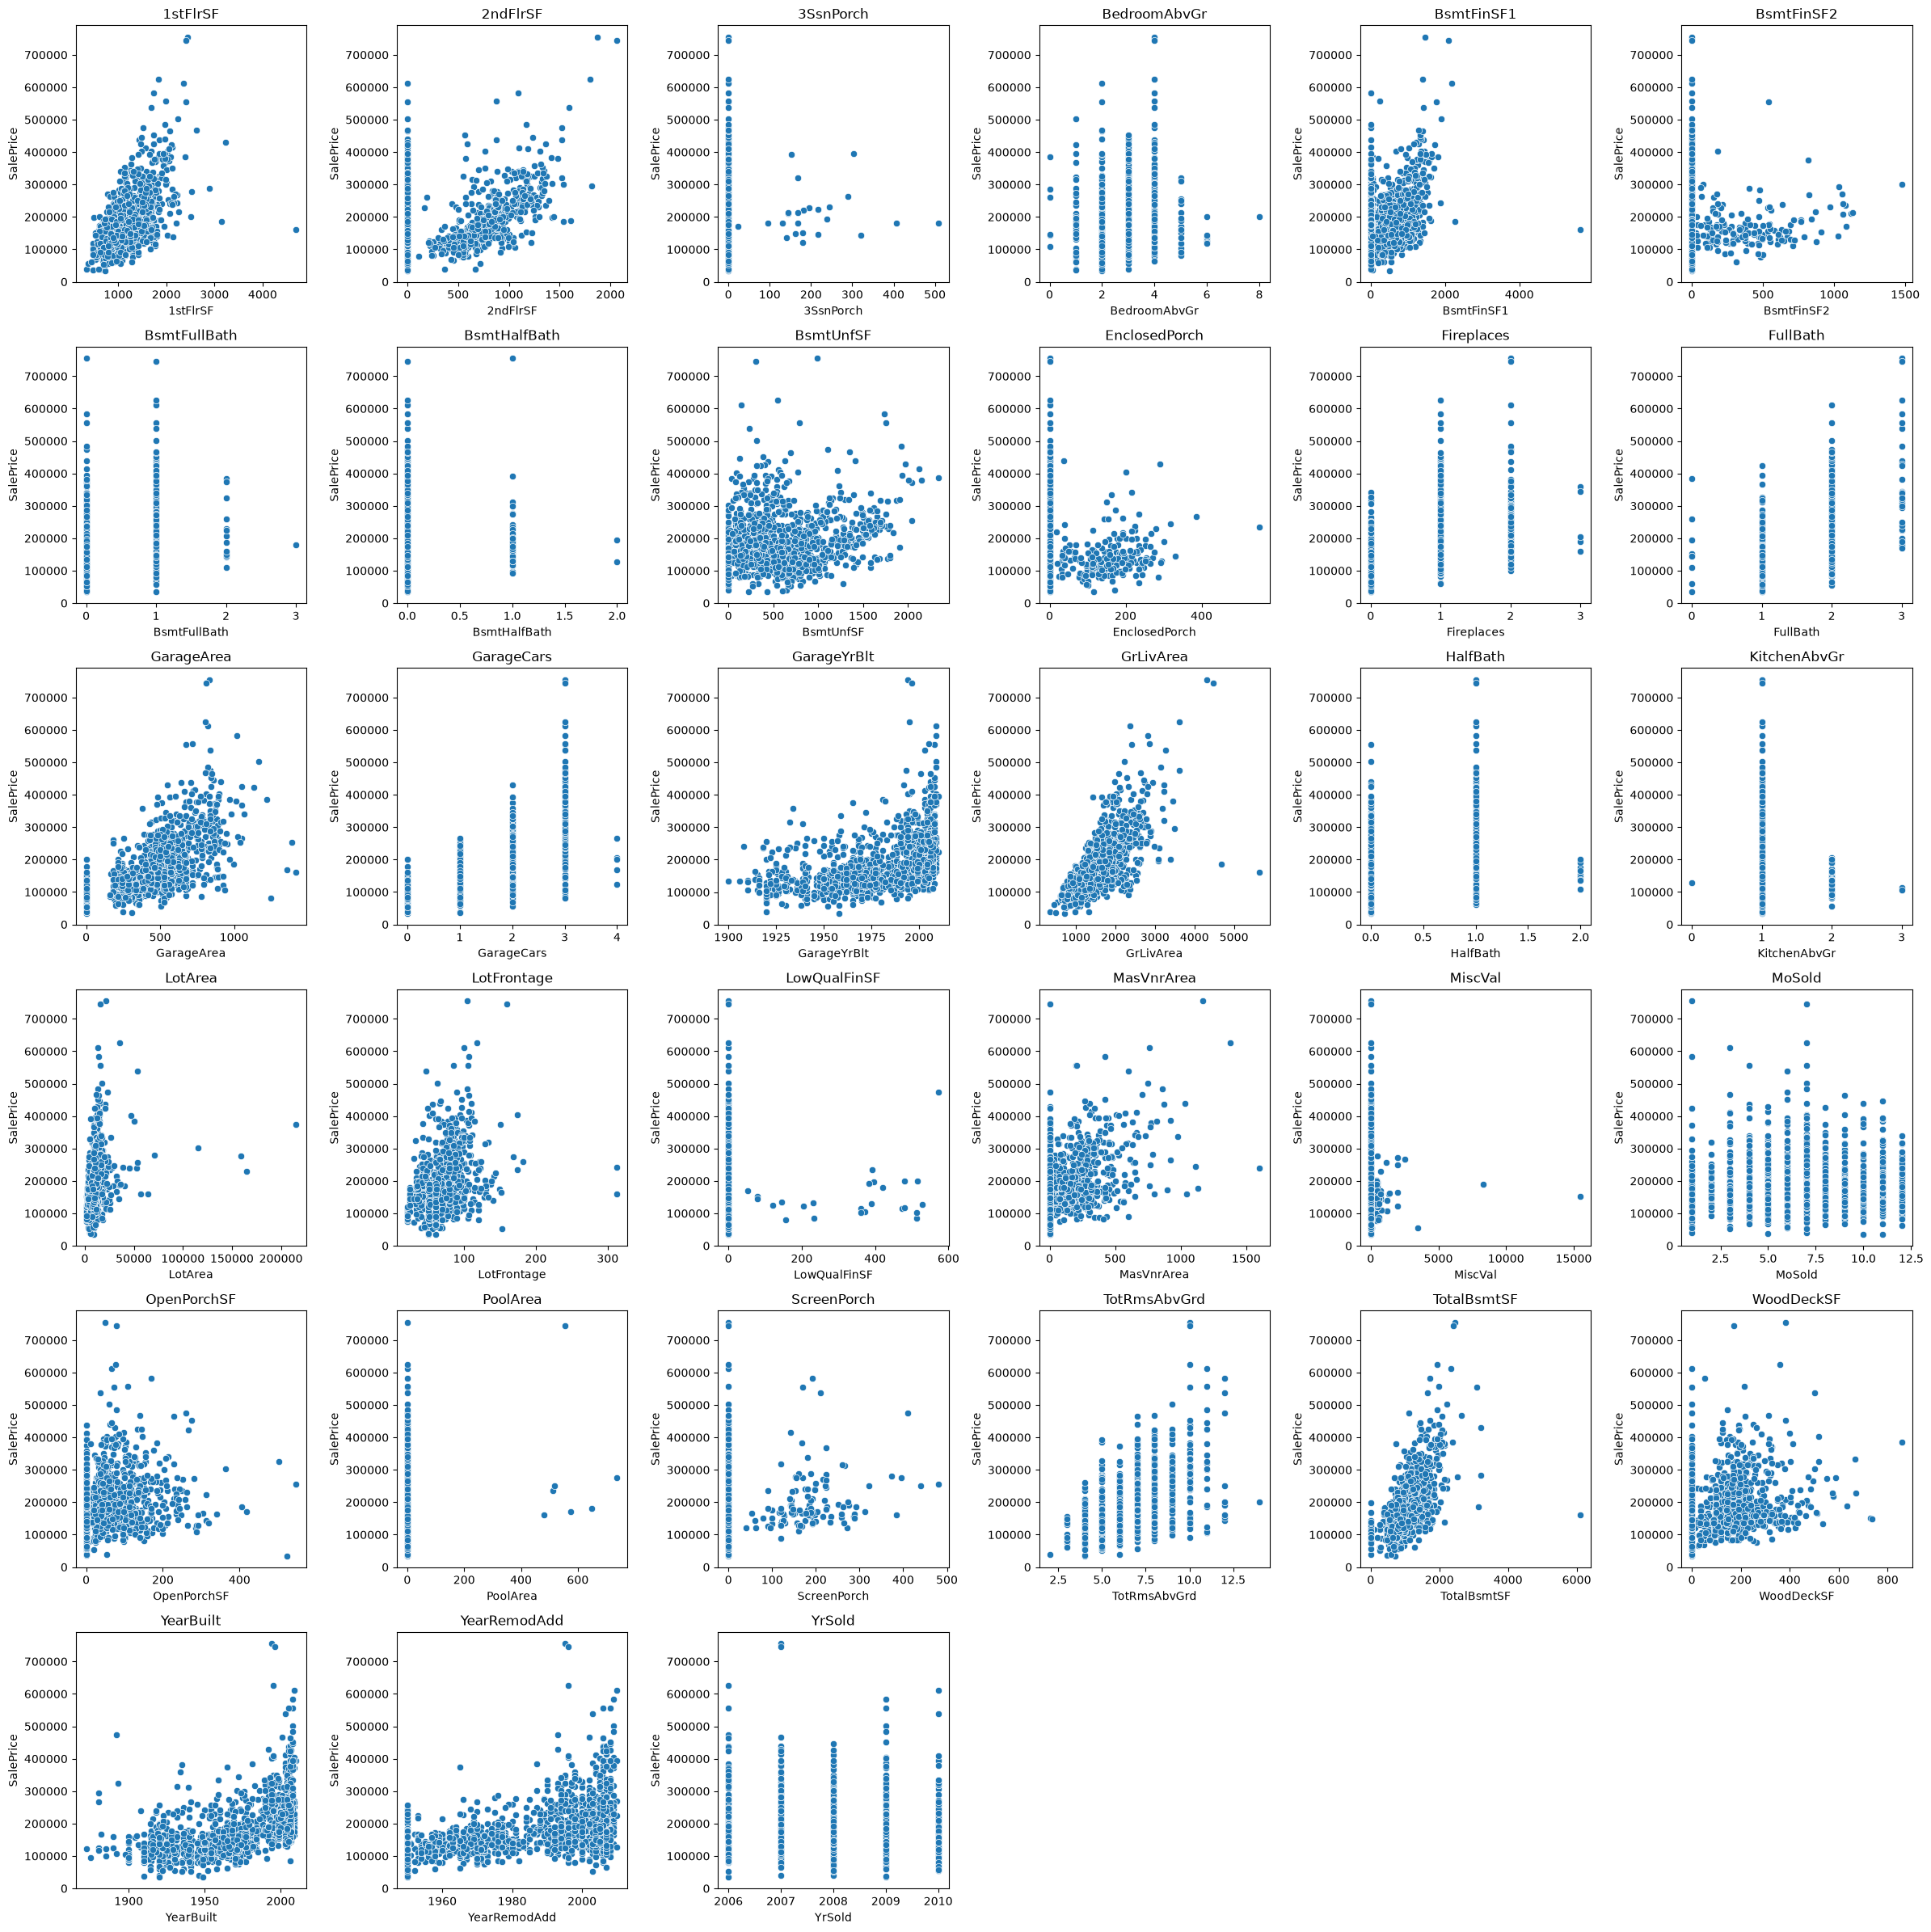

In [31]:
# scatter plot every numeric feature against the target, in a grid
ncols = 6
nrows = int(np.ceil(len(NUMERIC_COLS) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 24))

for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.scatterplot(x=df_train[col], y=df_train["SalePrice"], ax=ax)
    ax.set_title(col)

# hide any unused grid slots (33 cols don't fill a 6x6=36 grid)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis('off')

plt.tight_layout()


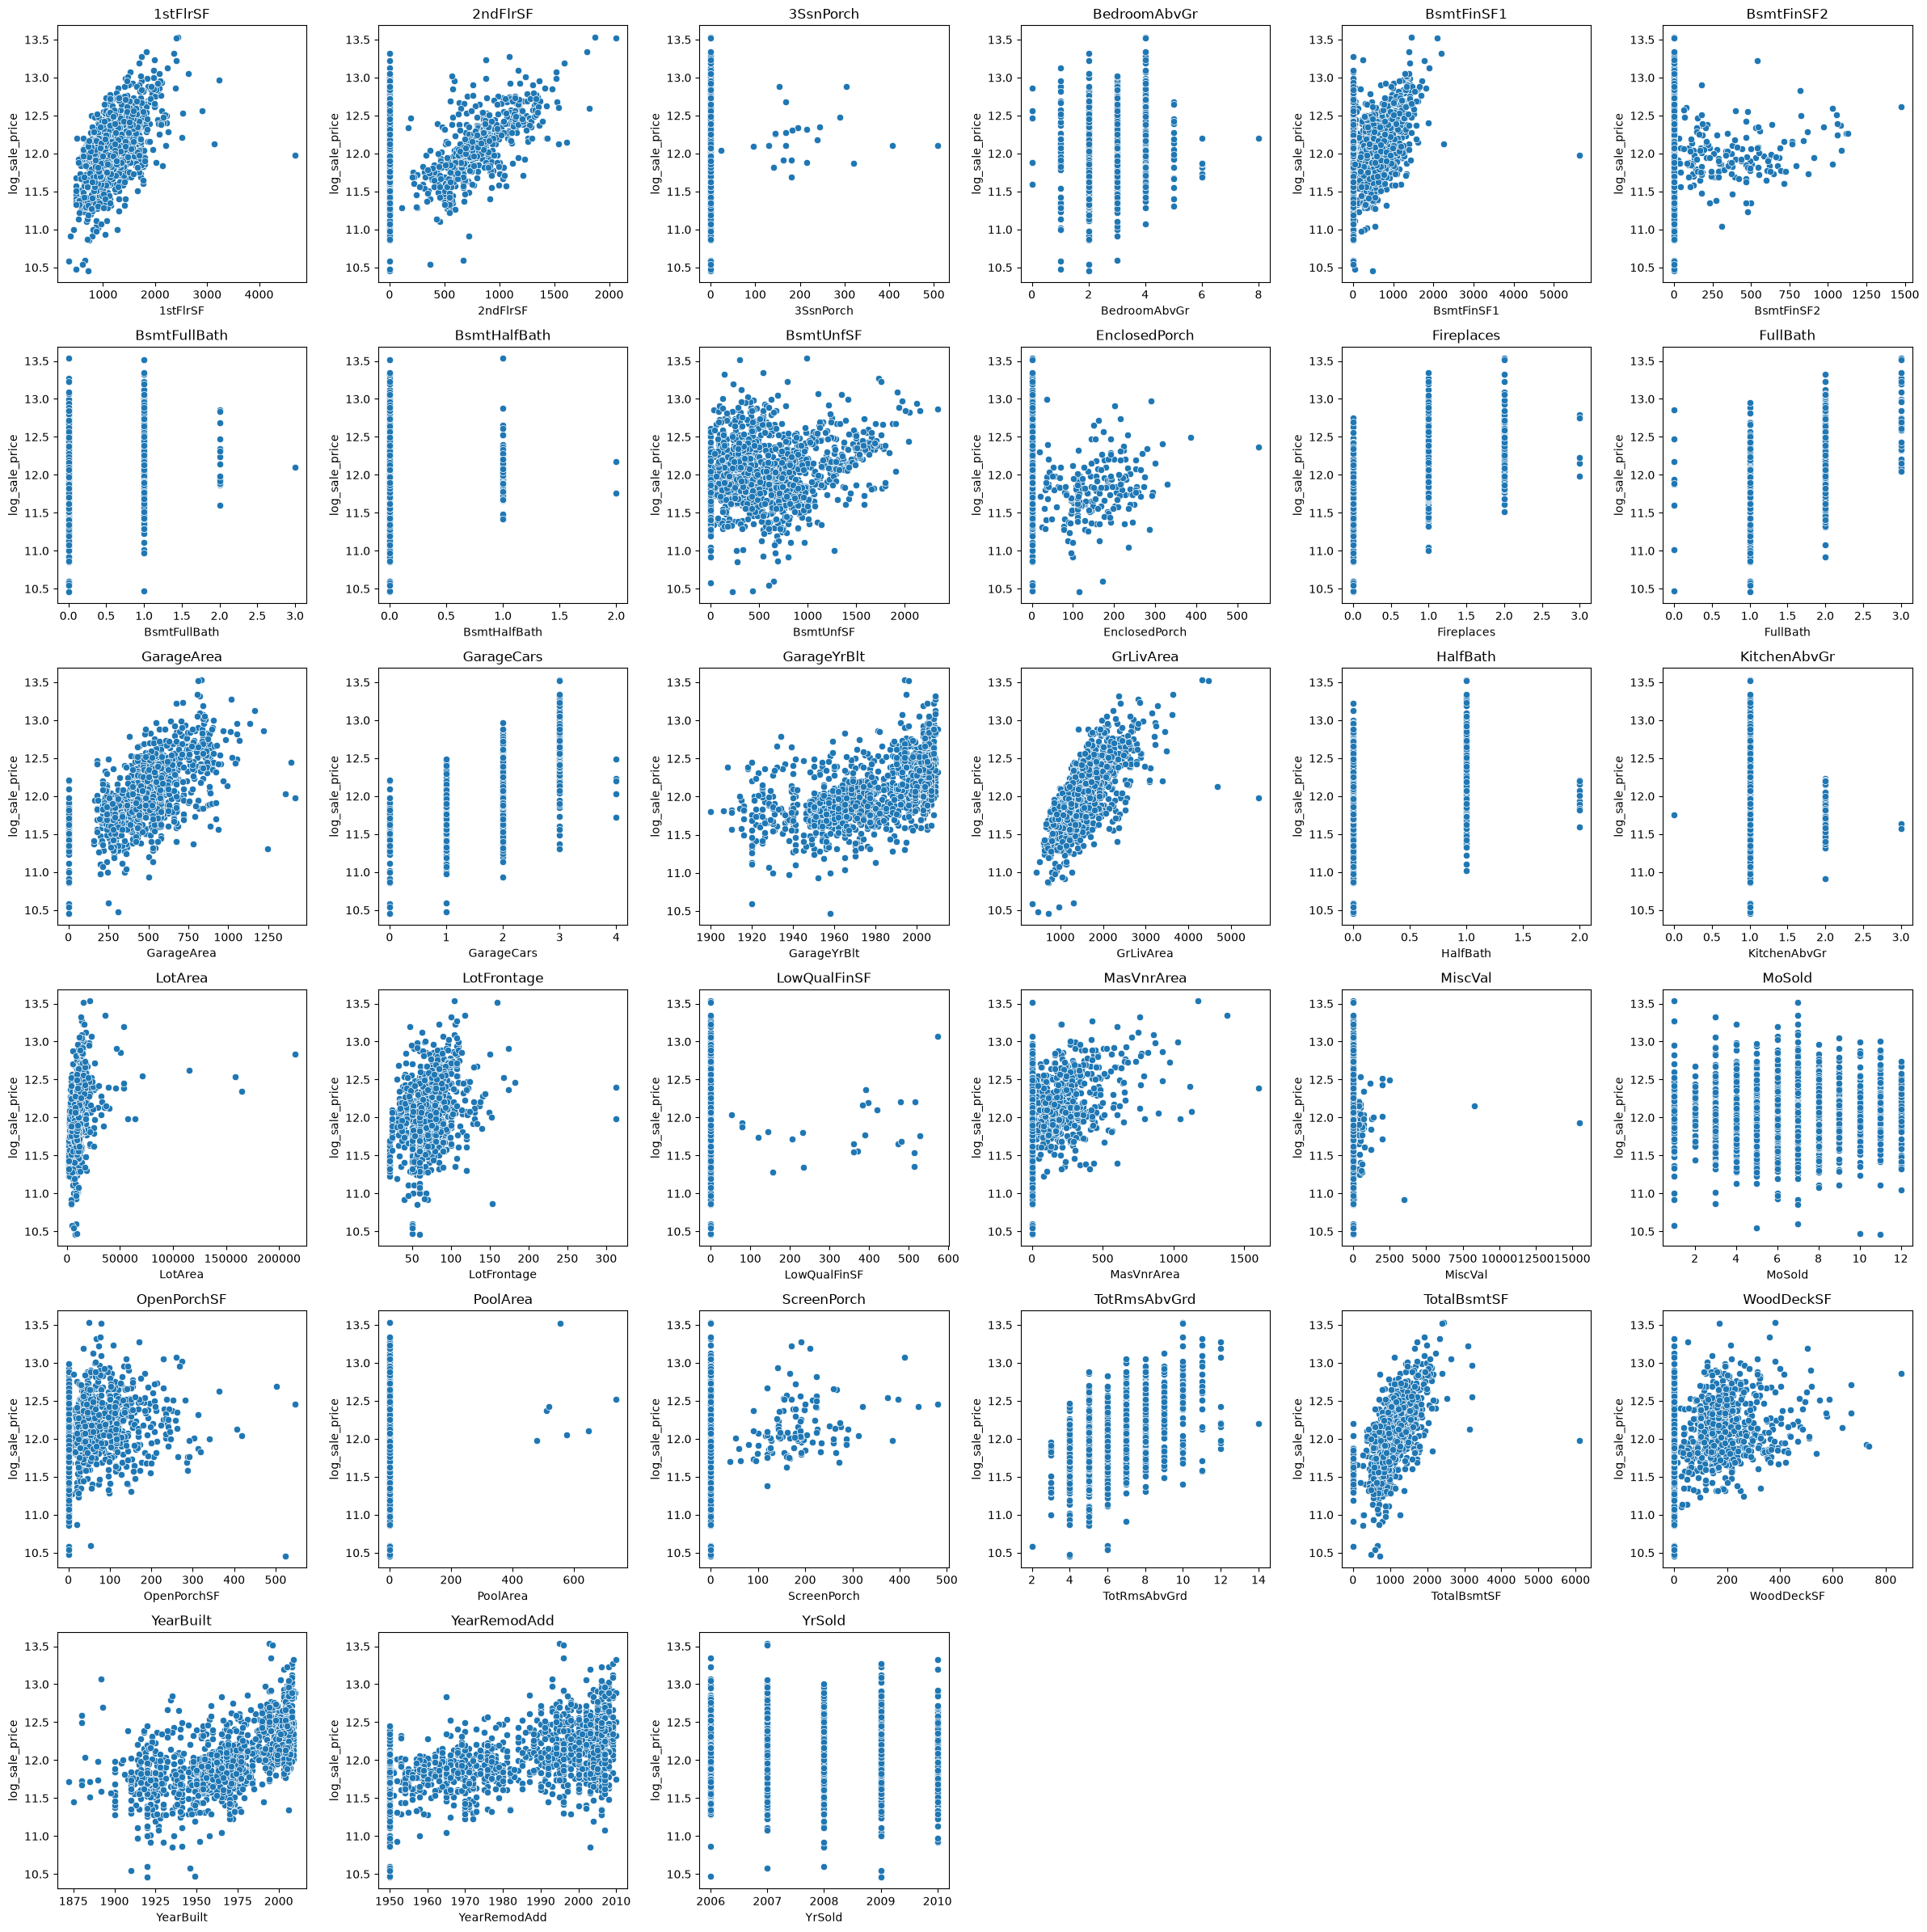

In [32]:
# scatter plot every numeric feature against the (log) target, in a grid
ncols = 6
nrows = int(np.ceil(len(NUMERIC_COLS) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 24))

for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.scatterplot(x=df_train[col], y=log_sale_price, ax=ax)
    ax.set_title(col)

# hide any unused grid slots (33 cols don't fill a 6x6=36 grid)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis('off')

plt.tight_layout()

In [33]:
xt, lam = boxcox(df_train["SalePrice"])
print(lam)

-0.07692397686078907


In [34]:
xt

array([7.93260785, 7.87826076, 7.95961541, ..., 8.02737914, 7.78100329,
       7.79588451], shape=(1460,))

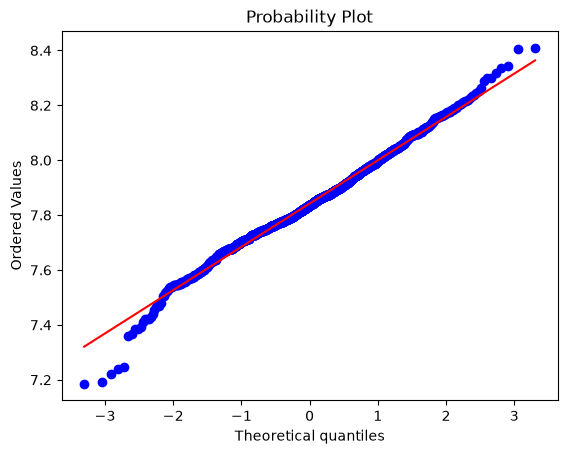

In [35]:
probplot(xt, plot=plt)
plt.show()

### Decision: model on `log_sale_price`

Raw `SalePrice` is heavily right-skewed (skew 1.88, kurtosis 6.54), confirmed
visually by the QQ-plot's one-sided tail deviation — the right tail bows
sharply off the reference line while the left tail stays close to it.
`log1p(SalePrice)` is close to symmetric (skew 0.12, kurtosis 0.81) with a
QQ-plot that tracks the reference line except at the extreme tails.

Box-Cox was also checked as a comparison: the fitted λ ≈ -0.077, close to 0
(the log special case), so it doesn't meaningfully outperform a plain log
here and adds a fitted parameter to carry around for the inverse transform.

Going forward, `log_sale_price` is the modeling target. Predictions get
`expm1`-transformed back to raw dollars for evaluation/submission.

### Summary — Target: `SalePrice`

| Check | Value |
|---|---|
| Nulls | 0 |
| Min / Max | 34,900 / 755,000 |
| Mean / Median | 180,921 / 163,000 |
| Std | 79,443 |
| IQR outliers (raw, 1.5×IQR) | 61 rows |

**Distribution shape: raw vs. transformed**

| Version | Skew | Kurtosis | IQR outliers | QQ-plot fit |
|---|---|---|---|---|
| Raw `SalePrice` | 1.88 | 6.54 | 61 | right tail bows sharply off the line |
| `log1p(SalePrice)` | 0.12 | 0.81 | 28 (15 low / 13 high) | tracks the line except at extreme tails |
| Standard-scaled `SalePrice` | 1.88 | 6.54 | — | same shape as raw (scaling doesn't fix skew) |
| Standard-scaled log `SalePrice` | 0.12 | 0.81 | — | same shape as log (scaling doesn't change it) |
| Box-Cox `SalePrice` | — | — | — | λ ≈ -0.077, close to 0 → ≈ log, no real gain |

**Most skewed numeric features** (candidates for their own transform later): `MiscVal` (24.5), `PoolArea` (14.8), `LotArea` (12.2), `3SsnPorch` (10.3), `LowQualFinSF` (9.0).

**Most zero-heavy numeric features** (near-constant / presence-flag candidates): `PoolArea` (99.5%), `3SsnPorch` (98.4%), `LowQualFinSF` (98.2%), `MiscVal` (96.4%), `BsmtHalfBath` (94.4%).

**Decision: model on `log_sale_price`**

Raw `SalePrice` is heavily right-skewed; `log1p` brings skew and kurtosis close to normal and roughly halves the IQR-outlier count (61 → 28). Box-Cox's fitted λ is close enough to 0 that it doesn't outperform a plain log while adding a parameter to carry around for inversion. Going forward, `log_sale_price` is the modeling target — predictions get `expm1`-transformed back to raw dollars for evaluation/submission.

**Takeaways**
- Target has no missing values — no imputation needed for `SalePrice` itself.
- Scaling (standardization) does not fix skew — only a shape transform (log/Box-Cox) does; that's why scaling and log are evaluated separately above.
- Several numeric features are extremely skewed/zero-heavy independent of the target and may need their own transform or binarization in preprocessing — noted here for follow-up, not acted on in this notebook.